# 06 — Model Selection & Hyperparameter Tuning

Every algorithm so far had hyperparameters we mostly left at defaults or
picked by eye (`max_depth`, `k`, `C`, `alpha`, ...). This notebook covers the
systematic way to choose them: **Pipelines** to avoid leaking test data into
preprocessing, **GridSearchCV**/**RandomizedSearchCV** to search
hyperparameters properly under cross-validation, and **learning/validation
curves** to diagnose *why* a model is underperforming.

**Covered:**
1. Pipelines & ColumnTransformer
2. GridSearchCV
3. RandomizedSearchCV
4. Learning curves
5. Validation curves

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(5)

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5, stratify=y)

## 1. Pipelines & ColumnTransformer

**Theory.** A `Pipeline` chains preprocessing steps and a final estimator
into a single object with one `.fit()`/`.predict()` interface. This isn't
just convenience — it's a **correctness** requirement: if you scale using
statistics computed on the *entire* dataset (train + test) before splitting,
information from the test set leaks into training, giving overly optimistic
scores. A pipeline, combined with cross-validation, refits preprocessing
fresh on each training fold, exactly as it should be.

`ColumnTransformer` extends this to apply *different* preprocessing to
different columns (e.g., scale numeric columns, one-hot encode categorical
ones) within the same pipeline.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Simulate a mixed numeric + categorical dataset to show ColumnTransformer in action
df = pd.DataFrame(X, columns=data.feature_names)
df["clinic_region"] = rng.choice(["north", "south", "east", "west"], size=len(df))
df.loc[rng.choice(df.index, 10, replace=False), "mean radius"] = np.nan  # inject some missing values

numeric_features = data.feature_names.tolist()
categorical_features = ["clinic_region"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

full_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=5000)),
])

df_train, df_test, y_train_p, y_test_p = train_test_split(df, y, test_size=0.2, random_state=5, stratify=y)
full_pipeline.fit(df_train, y_train_p)
print(f"Pipeline test accuracy: {full_pipeline.score(df_test, y_test_p):.3f}")

Pipeline test accuracy: 0.974


Everything — imputation, scaling, encoding, model fitting — happens inside
`full_pipeline.fit(...)`. Cross-validating this single object (next section)
correctly refits every preprocessing step per fold, with zero leakage risk.

## 2. GridSearchCV

**Theory.** Exhaustively tries every combination of hyperparameters in a
specified grid, evaluating each with cross-validation, and keeps the
combination with the best mean CV score. Simple and guaranteed to check
every combination — but the cost grows multiplicatively with the number of
hyperparameters and values, so it's best for smallish search spaces.

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svm_pipeline = Pipeline([("scale", StandardScaler()), ("svm", SVC())])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1],
}

grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.3f}")
print(f"Test accuracy: {grid_search.score(X_test, y_test):.3f}")

Best params: {'svm__C': 10, 'svm__gamma': 0.01}
Best CV accuracy: 0.980
Test accuracy: 0.982


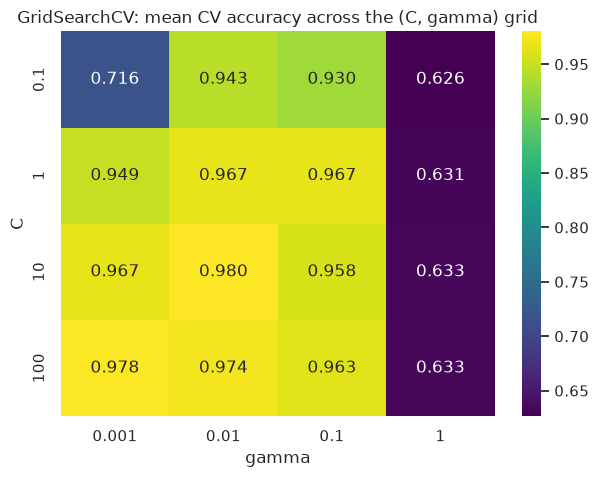

In [4]:
scores = grid_search.cv_results_["mean_test_score"].reshape(len(param_grid["svm__C"]), len(param_grid["svm__gamma"]))

plt.figure(figsize=(7, 5))
sns.heatmap(scores, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=param_grid["svm__gamma"], yticklabels=param_grid["svm__C"])
plt.xlabel("gamma")
plt.ylabel("C")
plt.title("GridSearchCV: mean CV accuracy across the (C, gamma) grid")
plt.show()

The heatmap makes the tradeoff visible directly: too-small `C` (strong
regularization, underfits) or a poorly matched `gamma` both hurt accuracy,
and the best region is a contiguous "sweet spot" rather than a single
isolated cell — a good sign that the result isn't a fluke of
cross-validation noise.

## 3. RandomizedSearchCV

**Theory.** Instead of trying every grid combination, sample a fixed number
of random combinations from specified distributions. Counter-intuitively,
this often finds equally good (or better) hyperparameters using far fewer
fits than a full grid search, especially when only a few hyperparameters
actually matter — random sampling explores more distinct values per
hyperparameter than a coarse grid does.

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.ensemble import RandomForestClassifier
import time

param_dist = {
    "n_estimators": np.arange(50, 500, 25),
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": np.arange(2, 20),
    "max_features": ["sqrt", "log2", None],
}

t0 = time.time()
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=5), param_dist, n_iter=25, cv=5,
    scoring="accuracy", random_state=5, n_jobs=-1,
)
random_search.fit(X_train, y_train)
random_time = time.time() - t0

print("Best params:", random_search.best_params_)
print(f"Best CV accuracy: {random_search.best_score_:.3f}  (searched 25 combos in {random_time:.1f}s)")
print(f"Test accuracy: {random_search.score(X_test, y_test):.3f}")

Best params: {'n_estimators': np.int64(100), 'min_samples_split': np.int64(4), 'max_features': 'sqrt', 'max_depth': 8}
Best CV accuracy: 0.960  (searched 25 combos in 14.8s)
Test accuracy: 0.965


In [6]:
# How many combinations would the equivalent full grid have needed?
full_grid_size = len(param_dist["n_estimators"]) * len(param_dist["max_depth"]) * \
                 len(param_dist["min_samples_split"]) * len(param_dist["max_features"])
print(f"Full grid would require {full_grid_size} combinations x 5 folds = {full_grid_size * 5} fits")
print(f"RandomizedSearchCV only needed 25 combinations x 5 folds = {25 * 5} fits")

Full grid would require 4860 combinations x 5 folds = 24300 fits
RandomizedSearchCV only needed 25 combinations x 5 folds = 125 fits


This is the practical argument for `RandomizedSearchCV`: as the number of
hyperparameters (and their ranges) grows, a full grid search becomes
computationally infeasible while random search's cost stays fixed at
`n_iter * cv` fits.

## 4. Learning Curves

**Theory.** Plots training and validation score as a function of **training
set size**. This diagnoses *what kind* of problem a model has:

- Both curves converge to a **low** score, close together → **high bias**
  (underfitting) — more data won't help; you need a more flexible model or
  better features.
- A **persistent gap** between a high training score and lower validation
  score → **high variance** (overfitting) — more data, regularization, or a
  simpler model would help.

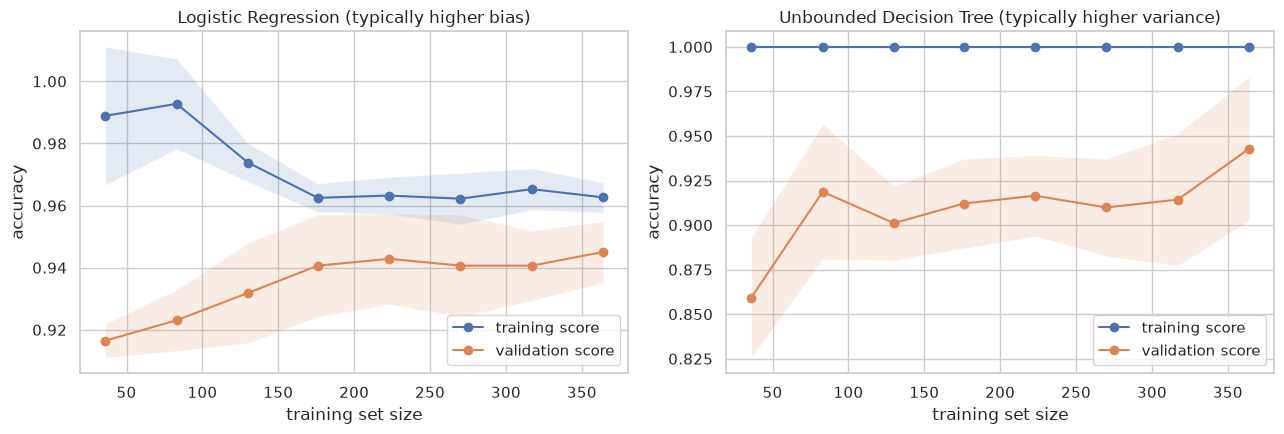

In [7]:
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, model, title in zip(
    axes,
    [LogisticRegression(max_iter=5000), DecisionTreeClassifier(max_depth=None, random_state=5)],
    ["Logistic Regression (typically higher bias)", "Unbounded Decision Tree (typically higher variance)"],
):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=5, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=5,
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="training score")
    ax.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="validation score")
    ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
    ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
    ax.set_xlabel("training set size")
    ax.set_ylabel("accuracy")
    ax.set_title(title)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

The decision tree's training score sits near-perfect the whole way (it can
memorize any amount of training data), leaving a visible gap to the
validation score — the signature of high variance. Logistic regression's two
curves sit closer together throughout, converging with more data.

## 5. Validation Curves

**Theory.** Like a learning curve, but sweeps **one hyperparameter** instead
of training set size, holding the dataset fixed. This directly shows where
a model transitions from underfitting to overfitting as complexity
increases — the same bias-variance U-shape from `00_foundations`, now driven
by a real hyperparameter instead of polynomial degree.

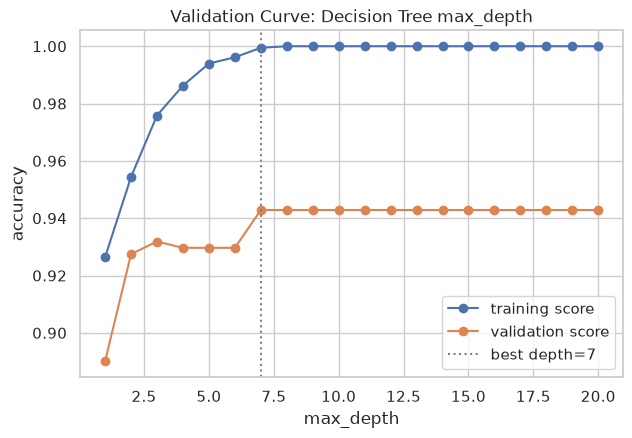

In [8]:
from sklearn.model_selection import validation_curve

depth_range = np.arange(1, 21)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=5), X_train, y_train,
    param_name="max_depth", param_range=depth_range, cv=5, scoring="accuracy",
)

plt.figure(figsize=(7, 4.5))
plt.plot(depth_range, train_scores.mean(axis=1), marker="o", label="training score")
plt.plot(depth_range, val_scores.mean(axis=1), marker="o", label="validation score")
best_depth = depth_range[np.argmax(val_scores.mean(axis=1))]
plt.axvline(best_depth, color="gray", linestyle=":", label=f"best depth={best_depth}")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Validation Curve: Decision Tree max_depth")
plt.legend()
plt.show()

Training accuracy keeps climbing toward 1.0 as `max_depth` grows (the tree
can always fit training data better with more splits), but validation
accuracy peaks early and then flattens or dips — exactly where
`GridSearchCV`/`RandomizedSearchCV` would land if `max_depth` were included
in the search space.

## Exercises

1. Add `"svm__kernel": ["rbf", "poly"]` to the `GridSearchCV` param grid — how many total fits does this add?
2. Increase `RandomizedSearchCV`'s `n_iter` from 25 to 50 — does the best CV score improve noticeably, or plateau?
3. Plot a validation curve for `RandomForestClassifier`'s `n_estimators` (try `range(10, 300, 20)`) — does more trees ever start to hurt validation accuracy?

## Key Takeaways

- Wrap preprocessing + model in a `Pipeline` before cross-validating or tuning — otherwise you risk data leakage and overly optimistic scores.
- `GridSearchCV` is exhaustive but expensive; `RandomizedSearchCV` scales better as the search space grows.
- Learning curves diagnose bias vs. variance by varying **data size**; validation curves do the same by varying **one hyperparameter** — both point to the same underlying tradeoff.